In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
df["quality"].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

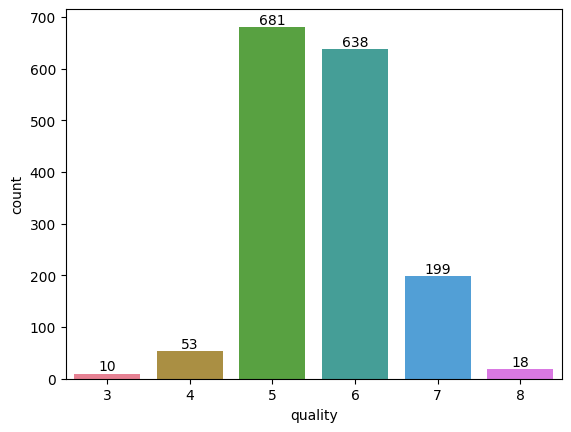

In [17]:
ax=sns.countplot(x="quality",data=df,palette="husl")
for container in ax.containers:
    ax.bar_label(container)

<Axes: xlabel='quality', ylabel='volatile acidity'>

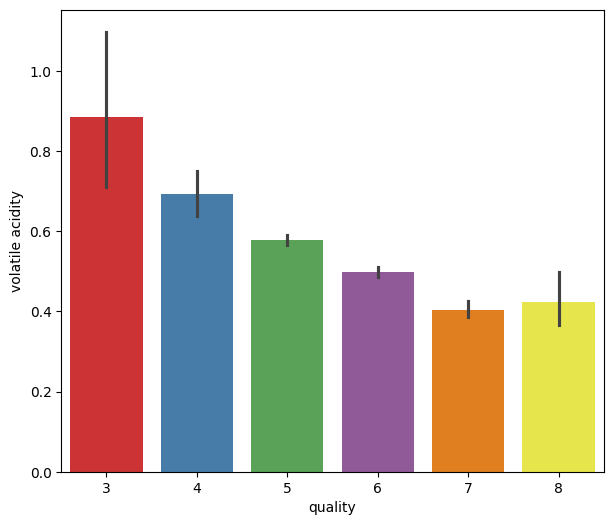

In [9]:
#volatile acidity vs quality
plt.figure(figsize=(7,6))
sns.barplot(x="quality",y="volatile acidity",data=df,palette="Set1")

<Axes: xlabel='quality', ylabel='citric acid'>

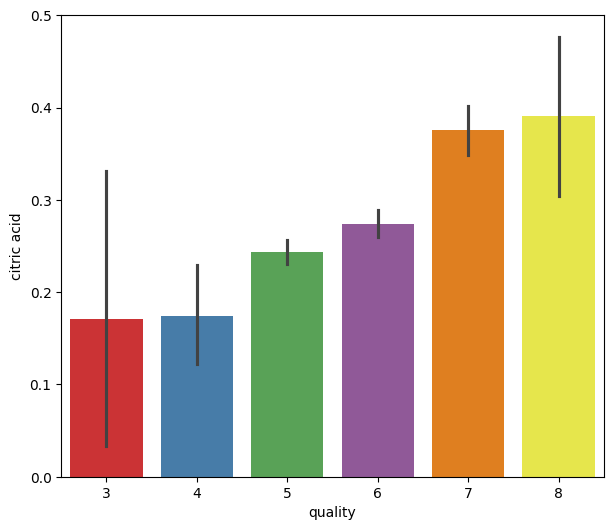

In [10]:
# Citric acid Vs Quality
plt.figure(figsize=(7,6))
sns.barplot(x="quality",y="citric acid",data=df,palette="Set1")

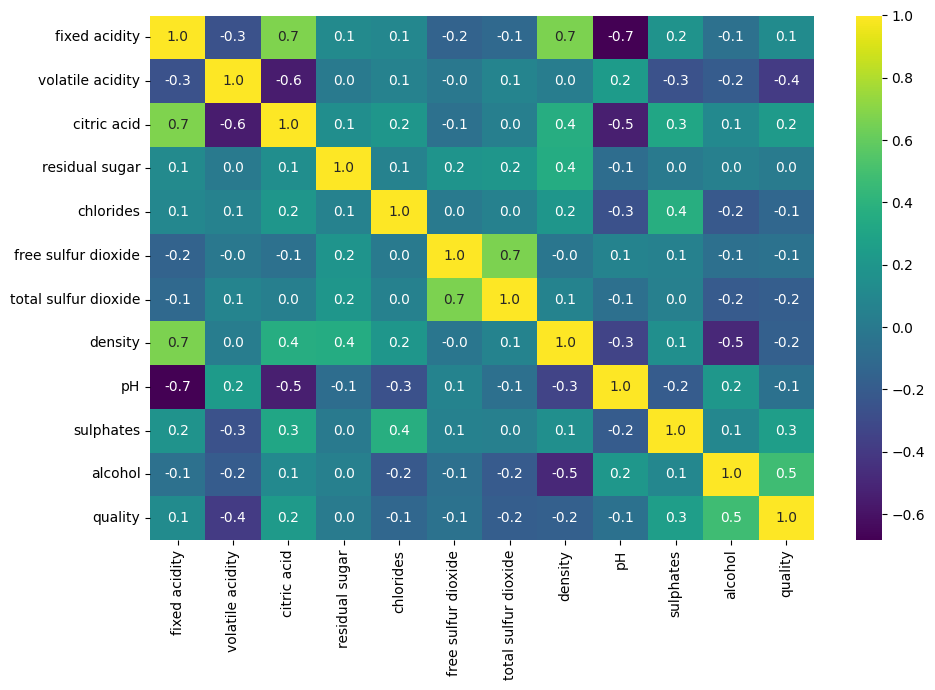

In [11]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt="0.1f",cmap="viridis")
plt.tight_layout()
plt.show()

**Seperate the columns into Dependent and Independent Variable**

In [12]:
X=df.drop("quality",axis=1)
y=df["quality"]

**Label Binarization**

In [13]:
def quality_label(label):
    if label<=6:
        return 0

    else:
        return 1

In [15]:
y=df["quality"].apply(quality_label)

In [16]:
y.value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [18]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
y_train.shape,y_test.shape

((1279,), (320,))

**Model Training**

In [23]:
rf=RandomForestClassifier(n_estimators=100)
rf.fit(X_train,y_train)

RandomForestClassifier()

In [24]:
y_pred=rf.predict(X_test)

In [25]:
acc_score=accuracy_score(y_test,y_pred)
print("Accuracy Score: ",acc_score)

Accuracy Score:  0.896875


In [61]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       273
           1       0.71      0.51      0.59        47

    accuracy                           0.90       320
   macro avg       0.81      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



Text(0.5, 23.52222222222222, 'Predicted')

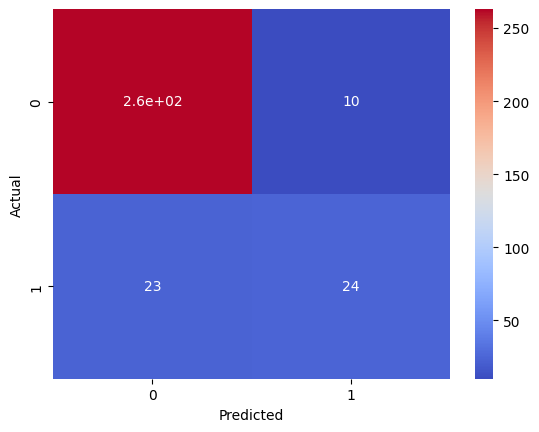

In [29]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,cmap="coolwarm")
plt.ylabel("Actual")
plt.xlabel("Predicted")

In [31]:
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [32]:
y_pred_lg=lg.predict(X_test)

In [33]:
acc_score_logistic=accuracy_score(y_test,y_pred_lg)

In [34]:
print("Accuracy Score for Logistic Regression: ",acc_score_logistic)

Accuracy Score for Logistic Regression:  0.865625


In [62]:
print(classification_report(y_test,y_pred_lg))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       273
           1       0.62      0.21      0.32        47

    accuracy                           0.87       320
   macro avg       0.75      0.60      0.62       320
weighted avg       0.84      0.87      0.84       320



Text(0.5, 23.52222222222222, 'Predicted')

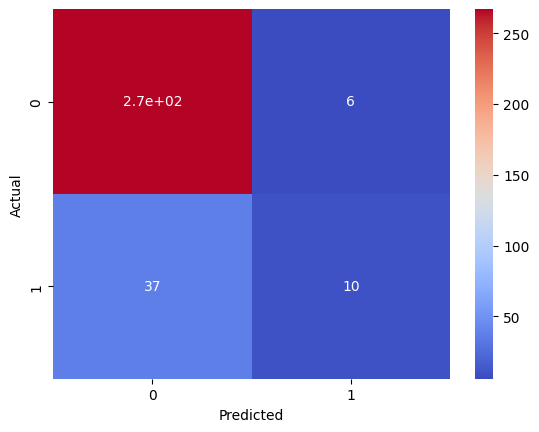

In [35]:
cm=confusion_matrix(y_test,y_pred_lg)
sns.heatmap(cm,annot=True,cmap="coolwarm")
plt.ylabel("Actual")
plt.xlabel("Predicted")

In [44]:
dt=DecisionTreeClassifier(max_depth=5,criterion="entropy")
dt.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [45]:
y_pred_dt=dt.predict(X_test)

In [46]:
acc_score_dt=accuracy_score(y_test,y_pred_dt)
print("Accuracy Score for Decisiion Tree: ",acc_score_dt)

Accuracy Score for Decisiion Tree:  0.896875


In [63]:
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       273
           1       0.71      0.51      0.59        47

    accuracy                           0.90       320
   macro avg       0.81      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



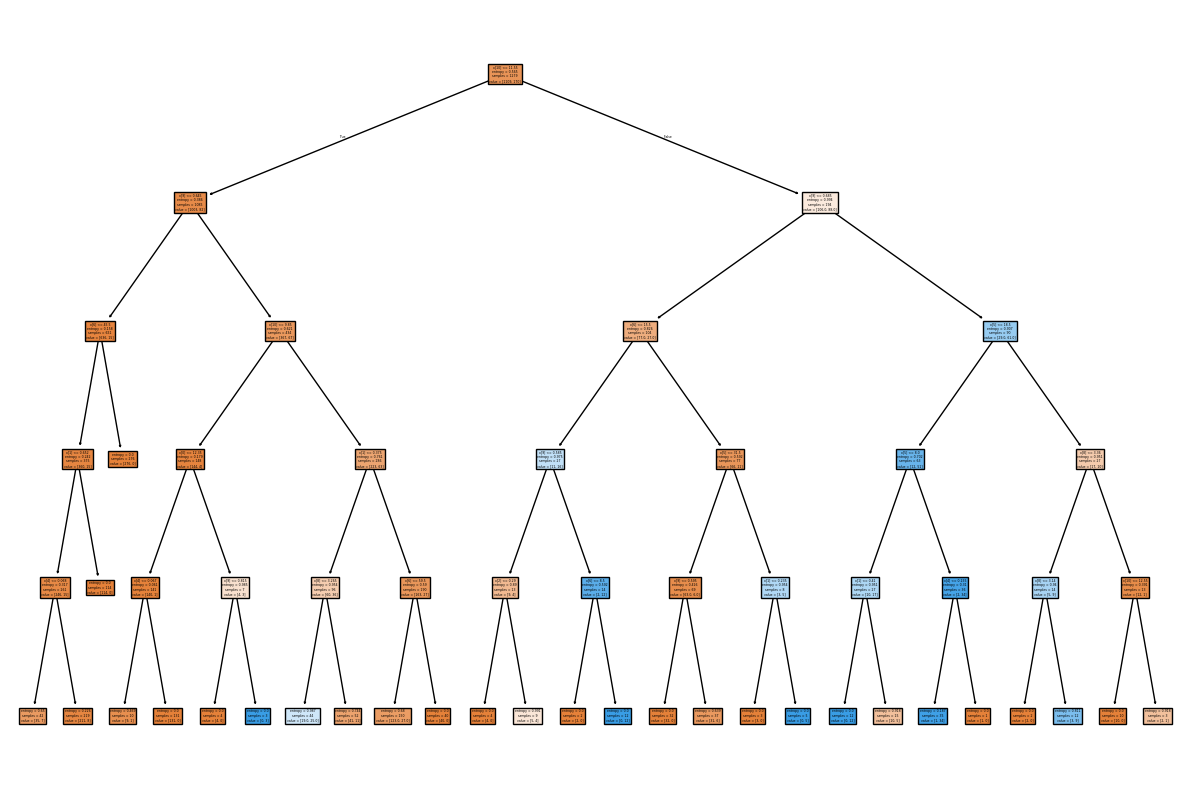

In [50]:
plt.figure(figsize=(12,8))
plot_tree(dt,filled=True)
plt.tight_layout()
plt.show()

Text(0.5, 23.52222222222222, 'Predicted')

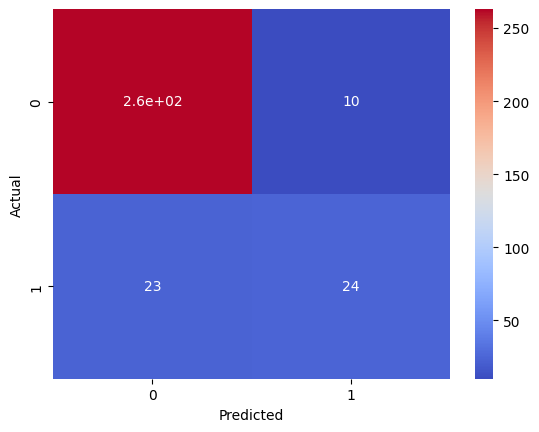

In [51]:
cm=confusion_matrix(y_test,y_pred_dt)
sns.heatmap(cm,annot=True,cmap="coolwarm")
plt.ylabel("Actual")
plt.xlabel("Predicted")

**Building a Predictive System**

In [55]:
rf.predict([[9.1,0.765,0.04,1.60,0.078,4.0,14.0,0.99800,3.29,0.54,9.7]])

array([0])

In [58]:
input_data=(9.1,0.765,0.04,1.60,0.078,4.0,14.0,0.99800,3.29,0.54,9.7)

#Changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#Reshape the data as we are predicting the label only one instance
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

prediction=rf.predict(input_data_reshape)
print(prediction)
if (prediction[0]==1):
    print("Good Quality Wine")
else:
    print("Bad Quality Wine")

[0]
Bad Quality Wine
